In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_badinh=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_ba_dinh.csv')
df_bactuliem=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_bac_tu_liem.csv')
df_caugiay=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_cau_giay.csv')
df_dongda=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_dong_da.csv')
df_hadong=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_ha_dong.csv')
df_haibatrung=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_hai_ba_trung.csv')
df_hoankiem=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_hoan_kiem.csv')
df_hoangmai=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_hoang_mai.csv')
df_longbien=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_long_bien.csv')
df_namtuliem=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_nam_tu_liem.csv')
df_tayho=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_tay_ho.csv')
df_thanhxuan=pd.read_csv('C:\DataScientistProject\Hanoi-house-predicttion\data\hanoi_house_prices_in_thanh_xuan.csv')

df=pd.concat([df_badinh, df_bactuliem, df_caugiay, df_dongda, df_hadong, df_haibatrung, df_hoankiem, df_hoangmai, df_longbien, df_namtuliem, df_tayho, df_thanhxuan], ignore_index=True)
df.head()

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:3: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not w

,price,area,bedrooms,address
0,Giá: 24 tỷ,Diện tích: 40 m²,4 phòng ngủ,"Phố Văn Cao,\r\n ..."
1,"Giá: 10,5 tỷ",Diện tích: 42 m²,3 phòng ngủ,"Đường Kim Mã,\r\n ..."
2,"Giá: 6,5 tỷ",Diện tích: 22 m²,3 phòng ngủ,"Phố Quán Thánh,\r\n ..."
3,"Giá: 14,6 tỷ",Diện tích: 42 m²,4 phòng ngủ,"Phố Nguyễn Thái Học,\r\n ..."
4,Giá: 15 tỷ,Diện tích: 55 m²,6 phòng ngủ,"Đường Ngọc Hà,\r\n ..."


In [4]:
df.shape


(4620, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4620 entries, 0 to 4619
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   price     4620 non-null   object
 1   area      4620 non-null   object
 2   bedrooms  4403 non-null   object
 3   address   4620 non-null   object
dtypes: object(4)
memory usage: 144.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,address
count,4620,4620,4403,4620
unique,895,405,90,965
top,Giá: 12 tỷ,Diện tích: 50 m²,4 phòng ngủ,"Đường An Dương Vương,\r\n ..."
freq,72,245,963,99


In [7]:
df.isnull().sum()

price         0
area          0
bedrooms    217
address       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(113)

In [9]:
# 1. Làm sạch cột 'price' (Bỏ "Giá: ", " tỷ", thay dấu phẩy bằng dấu chấm)
df['price'] = df['price'].str.replace('Giá: ', '', regex=False)
df['price'] = df['price'].str.replace(' tỷ', '', regex=False)
df['price'] = df['price'].str.replace(',', '.', regex=False)  # Đổi "24,5" thành "24.5" để ép kiểu float
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 2. Làm sạch cột 'area' (Bỏ "Diện tích: ", " m²")
df['area'] = df['area'].str.replace('Diện tích: ', '', regex=False)
df['area'] = df['area'].str.replace(' m²', '', regex=False)
df['area'] = df['area'].str.replace(',', '.', regex=False)
df['area'] = pd.to_numeric(df['area'], errors='coerce')

# 3. Làm sạch cột 'bedrooms' (Bỏ " phòng ngủ")
df['bedrooms'] = df['bedrooms'].str.replace(' phòng ngủ', '', regex=False)
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')

# Hiển thị lại kết quả sau khi làm sạch
print(df.head())

   price  area  bedrooms                                            address
0   24.0    40       4.0  Phố Văn Cao,\r\n                              ...
1   10.5    42       3.0  Đường Kim Mã,\r\n                             ...
2    6.5    22       3.0  Phố Quán Thánh,\r\n                           ...
3   14.6    42       4.0  Phố Nguyễn Thái Học,\r\n                      ...
4   15.0    55       6.0  Đường Ngọc Hà,\r\n                            ...


In [10]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from geopy.distance import geodesic
from tqdm import tqdm


In [11]:
# Bật tính năng hiển thị thanh tiến trình của tqdm cho pandas
tqdm.pandas()

In [12]:
# ==========================================================
# STEP 1: LÀM SẠCH ĐỊA CHỈ & RÚT TRÍCH TÊN ĐƯỜNG
# ==========================================================
# 1. Xóa bỏ các ký tự xuống dòng \r\n và khoảng trắng thừa
df['address_clean'] = df['address'].str.replace(r'[\r\n\t]+', ' ', regex=True).str.strip()
df['address_clean'] = df['address_clean'].str.replace(r'\s+', ' ', regex=True)

# 2. Tách lấy tên đường/phố (phần chữ trước dấu phẩy đầu tiên)
df['street'] = df['address_clean'].str.split(',').str[0]

# 3. Thêm hậu tố địa lý để Geopy tìm kiếm chính xác hơn, tránh bị lệch sang tỉnh khác
df['street_for_geo'] = df['street'] + ", Việt Nam"

In [13]:
# ==========================================================
# STEP 2: TIẾN HÀNH LẤY TỌA ĐỘ (GEOCODING)
# ==========================================================
# Khởi tạo bộ định vị Nominatim (OpenStreetMap) - miễn phí
geolocator = Nominatim(user_agent="hanoi_housing_explorer_2026")

# Giới hạn tốc độ gọi API 1 giây/lần để không bị server chặn (block IP)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

print("🚀 Đang quét bản đồ để lấy tọa độ (Kinh độ/Vĩ độ)... Vui lòng đợi...")

# Chạy Geocoding trên cột tên đường (tỉ lệ thành công sẽ cao hơn địa chỉ chi tiết)
df['location'] = df['street_for_geo'].progress_apply(geocode)

# Tách thành 2 cột Vĩ độ (Latitude) và Kinh độ (Longitude)
df['latitude'] = df['location'].apply(lambda loc: loc.latitude if loc else None)
df['longitude'] = df['location'].apply(lambda loc: loc.longitude if loc else None)

🚀 Đang quét bản đồ để lấy tọa độ (Kinh độ/Vĩ độ)... Vui lòng đợi...


 37%|███▋      | 1690/4620 [28:15<47:10,  1.04it/s]  RateLimiter caught an error, retrying (0/2 tries). Called with (*('Đường Quốc lộ 6, Việt Nam',), **{}).
Traceback (most recent call last):
  File "c:\Users\htrgi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\urllib3\connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "c:\Users\htrgi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\urllib3\connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
  File "c:\Users\htrgi\AppData\Local\Python\pythoncore-3.14-64\Lib\http\client.py", line 1450, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "c:\Users\htrgi\AppData\Local\Python\pythoncore-3.14-64\Lib\http\client.py", line 336, in begin
    version, status, reason = self._read_status()
                              ~~~~~~~~~~~~~~~~~^^
  File "c:\Users\htrgi\AppData\Local\Python\pythoncore-3.14-64\Lib\http\client.py", line 297, in _read_statu

In [26]:
df = df[df['location'].notnull()]
df.head()

,price,area,bedrooms,address,address_clean,street,street_for_geo,location,latitude,longitude
0,24.0,40,4.0,"Phố Văn Cao,\r\n ...","Phố Văn Cao, Phường Ngọc Hà, Hà Nội",Phố Văn Cao,"Phố Văn Cao, Việt Nam","(Phố Văn Cao, Đồng Quốc Bình, Phường Gia Viên,...",20.837508,106.700662
1,10.5,42,3.0,"Đường Kim Mã,\r\n ...","Đường Kim Mã, Phường Ngọc Hà, Hà Nội",Đường Kim Mã,"Đường Kim Mã, Việt Nam","(Số nhà 2/2C khu Ngoại Giao Đoàn, phố Kim Mã đ...",21.030860,105.816663
2,6.5,22,3.0,"Phố Quán Thánh,\r\n ...","Phố Quán Thánh, Phường Ba Đình, Hà Nội",Phố Quán Thánh,"Phố Quán Thánh, Việt Nam","(Phố Quán Thánh, Hoè Nhai, Phường Ba Đình, Thà...",21.040377,105.846358
3,14.6,42,4.0,"Phố Nguyễn Thái Học,\r\n ...","Phố Nguyễn Thái Học, Phường Ba Đình, Hà Nội",Phố Nguyễn Thái Học,"Phố Nguyễn Thái Học, Việt Nam","(Phố Nguyễn Thái Học, Phường Ba Đình, Thành ph...",21.029311,105.840022
4,15.0,55,6.0,"Đường Ngọc Hà,\r\n ...","Đường Ngọc Hà, Phường Ba Đình, Hà Nội",Đường Ngọc Hà,"Đường Ngọc Hà, Việt Nam","(Đài Truyền hình Việt Nam, 43, Đường Nguyễn Ch...",21.025761,105.813065


In [ ]:
df=df.drop(columns=['address','address_clean','street','street_for_geo','location'])
df.head()

,price,area,bedrooms,latitude,longitude
0,24.0,40,4.0,20.837508,106.700662
1,10.5,42,3.0,21.030860,105.816663
2,6.5,22,3.0,21.040377,105.846358
3,14.6,42,4.0,21.029311,105.840022
4,15.0,55,6.0,21.025761,105.813065


In [36]:
# Tạo hàm ước lượng: Diện tích < 40m2 thường có 1 PN, < 80m2 có 2 PN, còn lại 3 PN
def estimate_bedrooms(row):
    if pd.isna(row['bedrooms']):
        if row['area'] < 40: return 1.0
        elif row['area'] < 80: return 2.0
        elif row['area']<120: return 3.0
        elif row['area']<160: return 4.0
        else : return 5.0
    return row['bedrooms']

df['bedrooms'] = df.apply(estimate_bedrooms, axis=1)

In [38]:
df.isnull().sum()

price        68
area          0
bedrooms      0
latitude      0
longitude     0
dtype: int64

In [39]:
df = df[df['price'].notnull()]
df.isnull().sum()

price        0
area         0
bedrooms     0
latitude     0
longitude    0
dtype: int64

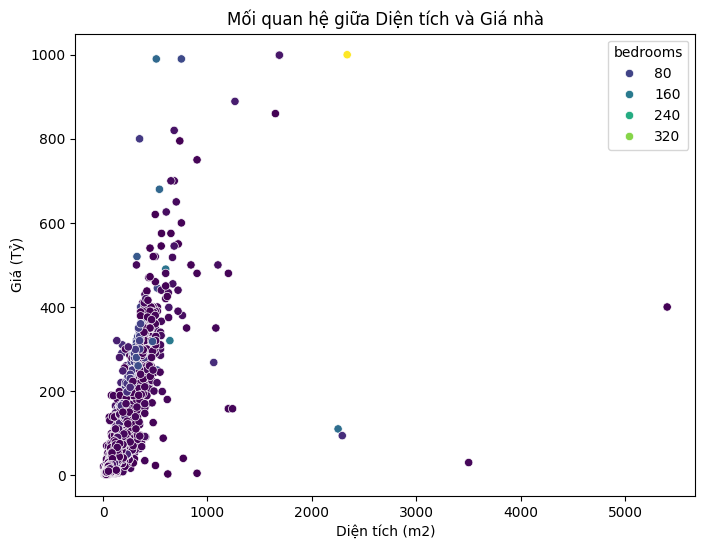

In [32]:
# Vẽ biểu đồ phân tán giữa Area và Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='area', y='price', hue='bedrooms', data=df, palette='viridis')
plt.title('Mối quan hệ giữa Diện tích và Giá nhà')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá (Tỷ)')
plt.show()

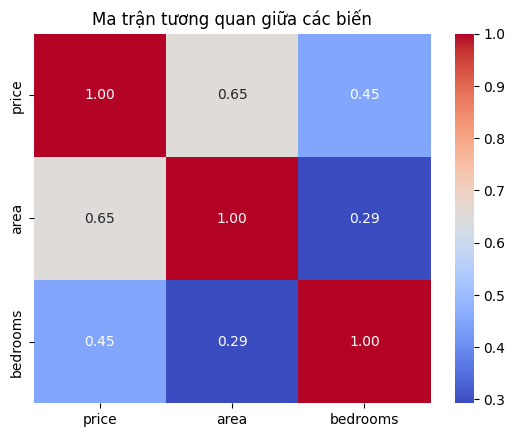

In [37]:
# Tính ma trận tương quan giữa các cột số
corr = df[['price', 'area', 'bedrooms']].corr()

# Vẽ biểu đồ nhiệt (Heatmap)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến')
plt.show()

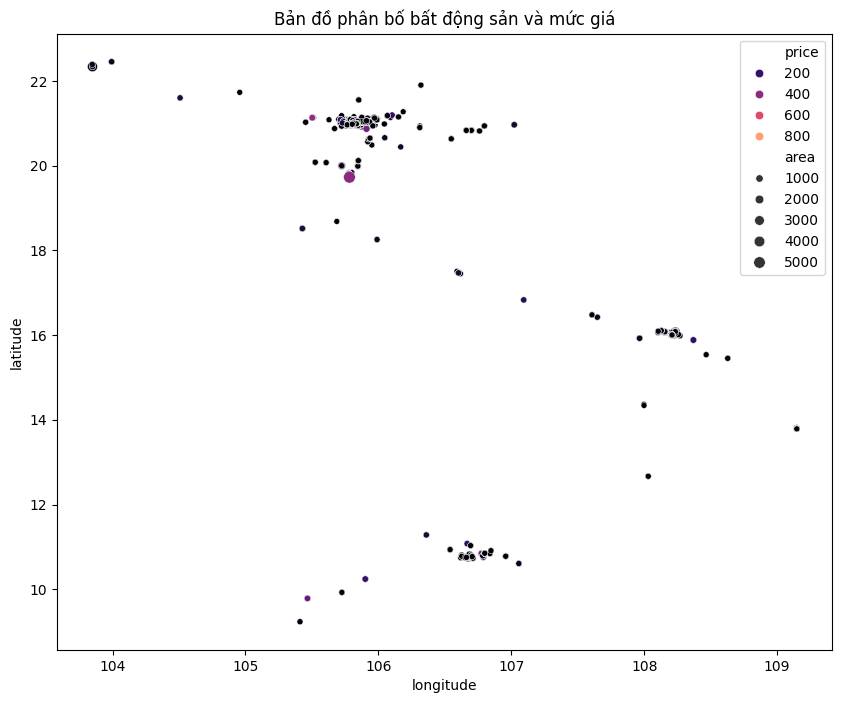

In [35]:
plt.figure(figsize=(10, 8))
# Trục X là Kinh độ, Y là Vĩ độ. Màu sắc (hue) đại diện cho Giá.
sns.scatterplot(x='longitude', y='latitude', hue='price', size='area', data=df, palette='magma')
plt.title('Bản đồ phân bố bất động sản và mức giá')
plt.show()

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4480 entries, 0 to 4619
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      4480 non-null   float64
 1   area       4480 non-null   int64  
 2   bedrooms   4480 non-null   float64
 3   latitude   4480 non-null   float64
 4   longitude  4480 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 210.0 KB


In [ ]:
df.to_csv('hanoi_house.csv')

: 